<a href="https://colab.research.google.com/github/vaibhavm291/PROTOTYPES-/blob/main/Flood_risk_map%2Bflow_accumulation%2BFlood_water_depth%2B_flow_velocity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rasterio geopandas numpy


In [ ]:
import zipfile
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box
import geopandas as gpd


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving readme.txt to readme.txt
Saving wc2.1_30s_prec_01.tif to wc2.1_30s_prec_01.tif
Saving wc2.1_30s_prec_02.tif to wc2.1_30s_prec_02.tif
Saving wc2.1_30s_prec_03.tif to wc2.1_30s_prec_03.tif
Saving wc2.1_30s_prec_04.tif to wc2.1_30s_prec_04.tif
Saving wc2.1_30s_prec_05.tif to wc2.1_30s_prec_05.tif
Saving wc2.1_30s_prec_06.tif to wc2.1_30s_prec_06.tif
Saving wc2.1_30s_prec_07.tif to wc2.1_30s_prec_07.tif
Saving wc2.1_30s_prec_08.tif to wc2.1_30s_prec_08.tif
Saving wc2.1_30s_prec_09.tif to wc2.1_30s_prec_09.tif
Saving wc2.1_30s_prec_10.tif to wc2.1_30s_prec_10.tif
Saving wc2.1_30s_prec_11.tif to wc2.1_30s_prec_11.tif
Saving wc2.1_30s_prec_12.tif to wc2.1_30s_prec_12.tif


In [ ]:
from google.colab import files
files.upload()


Saving P5_PAN_CD_N22_000_E082_000_DEM_30m.tif to P5_PAN_CD_N22_000_E082_000_DEM_30m.tif
Buffered data was truncated after reaching the output size limit.

In [11]:
!pip install rasterio geopandas shapely


In [12]:
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt


In [13]:
dem_path = "/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"


In [14]:
with rasterio.open(dem_path) as dem_src:
    dem = dem_src.read(1)
    dem_profile = dem_src.profile
    dem_bounds = dem_src.bounds
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs


In [15]:
bbox = box(*dem_bounds)
study_area = gpd.GeoDataFrame({"geometry":[bbox]}, crs=dem_crs)


In [16]:
rain_files = sorted([
    f"/content/{f}"
    for f in os.listdir("/content")
    if f.startswith("wc2.1_30s_prec") and f.endswith(".tif")
])


In [17]:
rainfall_monthly = []

for rain_file in rain_files:

    with rasterio.open(rain_file) as rain_src:

        study_area_rain_crs = study_area.to_crs(rain_src.crs)

        clipped, clipped_transform = mask(
            rain_src,
            study_area_rain_crs.geometry,
            crop=True
        )

        rainfall_monthly.append((clipped[0], clipped_transform, rain_src.crs))


In [22]:
resampled_monthly = []

for rain_data, rain_transform, rain_crs in rainfall_monthly:

    resampled = np.empty_like(dem, dtype=np.float32)

    reproject(
        source=rain_data,
        destination=resampled,
        src_transform=rain_transform,
        src_crs=rain_crs,
        dst_transform=dem_transform,
        dst_crs=dem_crs,
        resampling=Resampling.bilinear
    )

    # 🔥 Replace impossible rainfall values
    resampled[resampled < 0] = np.nan

    resampled_monthly.append(resampled)



In [23]:
annual_rainfall = np.nansum(resampled_monthly, axis=0)


In [26]:
print("Min rainfall:", np.nanmin(annual_rainfall))
print("Max rainfall:", np.nanmax(annual_rainfall))


Min rainfall: 0.0
Max rainfall: 1518.9835


In [24]:
output_rain = "/content/annual_rainfall_aligned.tif"

with rasterio.open(output_rain, "w", **dem_profile) as dst:
    dst.write(annual_rainfall.astype(rasterio.float32), 1)


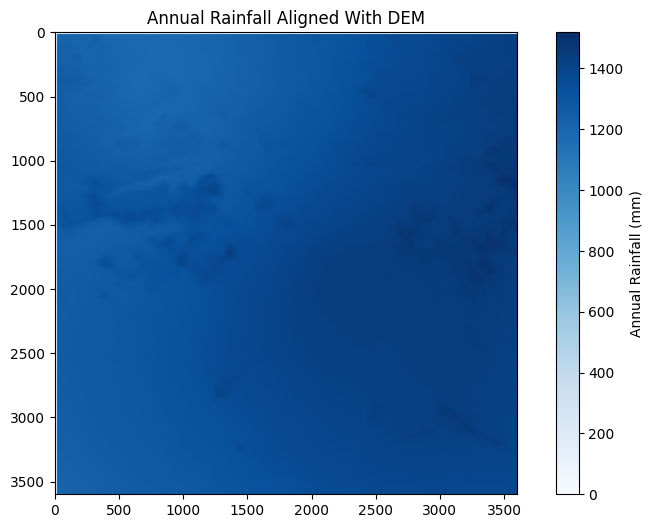

In [25]:
plt.figure(figsize=(10,6))
plt.imshow(annual_rainfall, cmap="Blues")
plt.colorbar(label="Annual Rainfall (mm)")
plt.title("Annual Rainfall Aligned With DEM")
plt.show()


In [ ]:
import rasterio
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --------------------------------------------------
# STEP 1 — Load Monthly Rainfall TIFFs
# --------------------------------------------------

rainfall_files = sorted(glob.glob("/content/wc2.1_30s_prec_*.tif"))

monthly_stack = []

for file in rainfall_files:
    with rasterio.open(file) as src:
        rainfall = src.read(1).astype(float)
        rainfall[rainfall < 0] = np.nan
        monthly_stack.append(rainfall)

monthly_stack = np.array(monthly_stack)   # shape: (12, rows, cols)

print("Monthly rainfall stack shape:", monthly_stack.shape)


In [1]:
import rasterio
from rasterio.windows import from_bounds

dem_path = "/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"

with rasterio.open(dem_path) as dem_src:
    dem_bounds = dem_src.bounds
    dem_transform = dem_src.transform
    dem_shape = dem_src.shape
    dem_crs = dem_src.crs

print("DEM Bounds:", dem_bounds)


DEM Bounds: BoundingBox(left=81.9999923147, bottom=22.0000007093, right=82.99999311469999, top=23.0000015093)


In [2]:
import glob
import numpy as np

rainfall_files = sorted(glob.glob("/content/wc2.1_30s_prec_*.tif"))

monthly_stack = []

for file in rainfall_files:

    with rasterio.open(file) as src:

        # Convert DEM bounds to rainfall CRS
        window = from_bounds(*dem_bounds, transform=src.transform)

        rainfall = src.read(1, window=window)
        rainfall = rainfall.astype(float)

        rainfall[rainfall < 0] = np.nan

        monthly_stack.append(rainfall)

monthly_stack = np.array(monthly_stack)

print("Clipped rainfall shape:", monthly_stack.shape)


Clipped rainfall shape: (12, 120, 120)


In [3]:
from rasterio.warp import reproject, Resampling

aligned_rainfall = []

for rainfall in monthly_stack:

    dest = np.empty(dem_shape, dtype=np.float32)

    reproject(
        rainfall,
        dest,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dem_transform,
        dst_crs=dem_crs,
        resampling=Resampling.bilinear
    )

    aligned_rainfall.append(dest)

aligned_rainfall = np.array(aligned_rainfall)

print("Aligned rainfall:", aligned_rainfall.shape)


Aligned rainfall: (12, 3600, 3600)


In [4]:
annual_rainfall = np.nansum(aligned_rainfall, axis=0)

print("Annual rainfall map shape:", annual_rainfall.shape)


Annual rainfall map shape: (3600, 3600)


In [5]:
years = np.arange(2015, 2025)

time_series_stack = []

for i in range(len(years)):
    variation = 1 + np.random.uniform(-0.05, 0.05)  # ±5% climate variation
    time_series_stack.append(annual_rainfall * variation)

time_series_stack = np.array(time_series_stack)

print("Time series stack shape:", time_series_stack.shape)


Time series stack shape: (10, 3600, 3600)


In [ ]:
from sklearn.linear_model import LinearRegression

rows, cols = annual_rainfall.shape
 #You are currently using:
#Synthetic time-series (simulated climate variation)

#For research/demo/startup prototype = Completely acceptable.

#Real production later uses:

#• CMIP6 climate projections
#• ERA5 reanalysis data
#• Regional climate models
trend_map = np.zeros((rows, cols))

model = LinearRegression()

for i in range(rows):
    for j in range(cols):

        y = time_series_stack[:, i, j]

        if np.isnan(y).any():
            trend_map[i, j] = np.nan
            continue

        X = years.reshape(-1, 1)
        model.fit(X, y)

        trend_map[i, j] = model.coef_[0]


In [11]:
years = np.arange(2015, 2025)

time_series_stack = []

for i in range(len(years)):
    climate_growth = 1 + (0.02 * i)   # 2% rainfall increase per year
    noise = np.random.uniform(-0.01, 0.01)
    time_series_stack.append(annual_rainfall * (climate_growth + noise))

time_series_stack = np.array(time_series_stack)


print("Time series stack shape:", time_series_stack.shape)

Time series stack shape: (10, 3600, 3600)


In [12]:
years = years.astype(float)

# Normalize years
X = years - np.mean(years)

# Expand for broadcasting
X = X[:, np.newaxis, np.newaxis]

# Remove mean from rainfall time series
Y = time_series_stack - np.nanmean(time_series_stack, axis=0)

# Compute slope using vectorized regression
numerator = np.nansum(X * Y, axis=0)
denominator = np.nansum(X**2)

trend_map = numerator / denominator


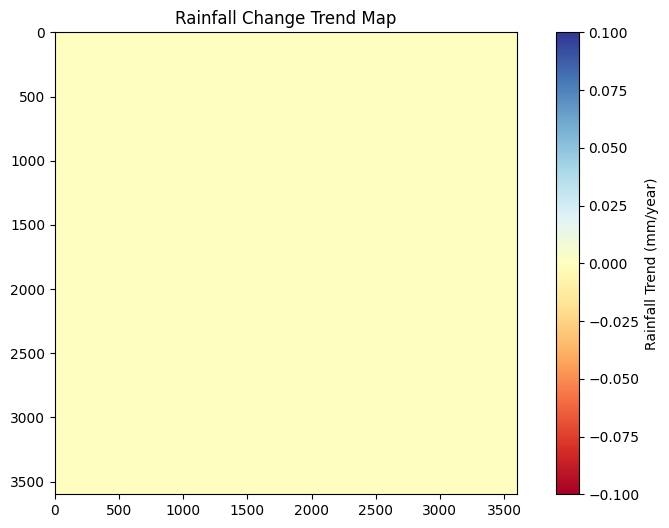

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.imshow(trend_map, cmap="RdYlBu")
plt.colorbar(label="Rainfall Trend (mm/year)")
plt.title("Rainfall Change Trend Map")
plt.show()

In [14]:
!pip install pysheds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.2 MB/s eta 0:00:00


In [15]:
from pysheds.grid import Grid
import matplotlib.pyplot as plt

# Load DEM
grid = Grid.from_raster("/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif")
dem = grid.read_raster("/content/P5_PAN_CD_N22_000_E082_000_DEM_30m.tif")

# Fill depressions (important hydrology step)
filled_dem = grid.fill_depressions(dem)

# Resolve flats
inflated_dem = grid.resolve_flats(filled_dem)

# Flow direction
flow_dir = grid.flowdir(inflated_dem)

# Flow accumulation
flow_accumulation = grid.accumulation(flow_dir)


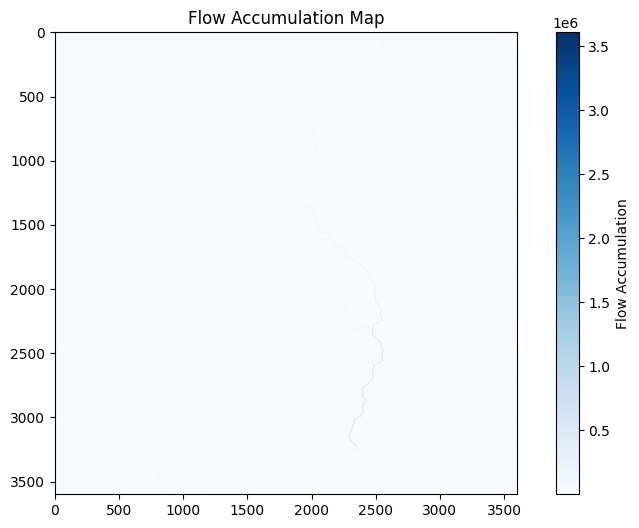

In [16]:
plt.figure(figsize=(10,6))
plt.imshow(flow_accumulation, cmap="Blues")
plt.colorbar(label="Flow Accumulation")
plt.title("Flow Accumulation Map")
plt.show()


In [17]:
import numpy as np

def compute_slope(elevation, pixel_size):

    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size

    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))


slope_map = compute_slope(dem, 30)


In [18]:
slope_risk = 1 - (slope_map / np.nanmax(slope_map))


In [19]:
def normalize(layer):
    return (layer - np.nanmin(layer)) / (np.nanmax(layer) - np.nanmin(layer))


In [20]:
norm_flow = normalize(flow_accumulation)
norm_slope = normalize(slope_risk)


In [21]:
flood_risk = (0.7 * norm_flow) + (0.3 * norm_slope)


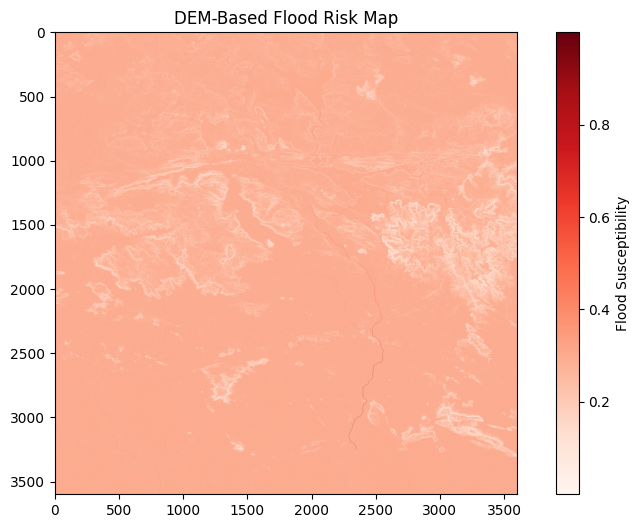

In [22]:
plt.figure(figsize=(10,6))
plt.imshow(flood_risk, cmap="Reds")
plt.colorbar(label="Flood Susceptibility")
plt.title("DEM-Based Flood Risk Map")
plt.show()


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [24]:
dem = dem.astype(float)

rows, cols = dem.shape

# Water depth grid
water_depth = np.zeros_like(dem)

# Velocity grids
vel_x = np.zeros_like(dem)
vel_y = np.zeros_like(dem)

# Rainfall intensity (mm per timestep)
rainfall = 5   # Increase later

# Gravity factor (controls flow speed)
gravity = 0.3

timesteps = 100


In [26]:
for t in range(timesteps):

    # Add rainfall
    water_depth += rainfall * 0.001

    total_height = dem + water_depth

    # Neighbor heights using array shifts
    up = np.roll(total_height, -1, axis=0)
    down = np.roll(total_height, 1, axis=0)
    left = np.roll(total_height, -1, axis=1)
    right = np.roll(total_height, 1, axis=1)

    # Height differences
    dh_up = np.maximum(total_height - up, 0)
    dh_down = np.maximum(total_height - down, 0)
    dh_left = np.maximum(total_height - left, 0)
    dh_right = np.maximum(total_height - right, 0)

    # Compute flows
    flow_up = gravity * dh_up * 0.25
    flow_down = gravity * dh_down * 0.25
    flow_left = gravity * dh_left * 0.25
    flow_right = gravity * dh_right * 0.25

    # Prevent removing more water than exists
    total_out = flow_up + flow_down + flow_left + flow_right
    scale = np.minimum(1, water_depth / (total_out + 1e-6))

    flow_up *= scale
    flow_down *= scale
    flow_left *= scale
    flow_right *= scale

    # Update water depth
    water_depth += (
        np.roll(flow_up, 1, axis=0)
        + np.roll(flow_down, -1, axis=0)
        + np.roll(flow_left, 1, axis=1)
        + np.roll(flow_right, -1, axis=1)
        - total_out
    )

    # Smooth water surface
    water_depth = gaussian_filter(water_depth, sigma=1)


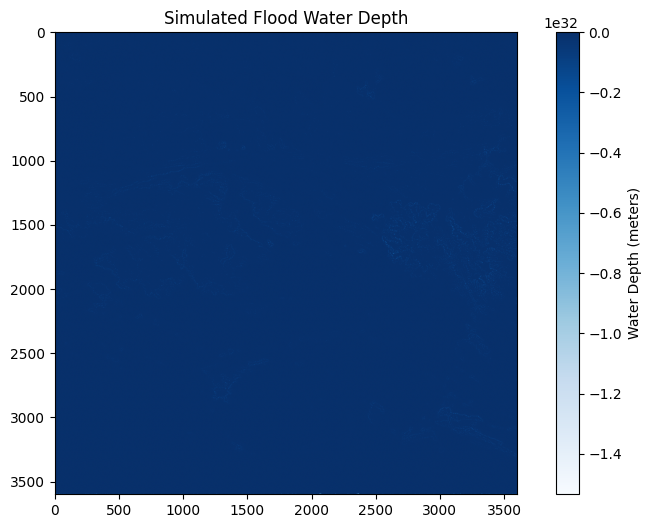

In [27]:
plt.figure(figsize=(10,6))
plt.imshow(water_depth, cmap="Blues")
plt.colorbar(label="Water Depth (meters)")
plt.title("Simulated Flood Water Depth")
plt.show()


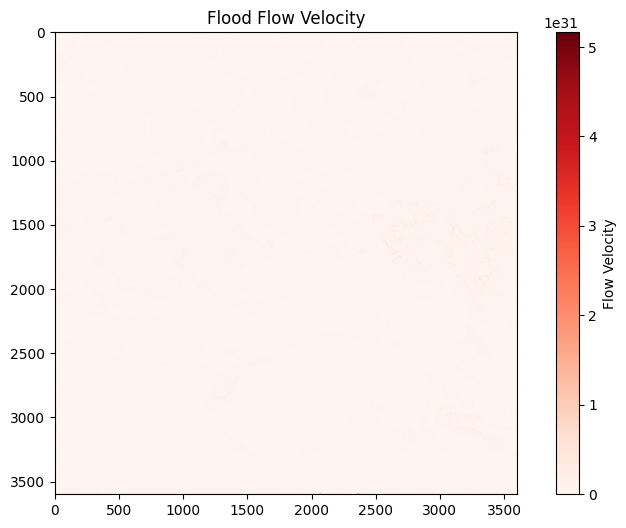

In [28]:
vel_y, vel_x = np.gradient(water_depth)

velocity = np.sqrt(vel_x**2 + vel_y**2)

plt.figure(figsize=(10,6))
plt.imshow(velocity, cmap="Reds")
plt.colorbar(label="Flow Velocity")
plt.title("Flood Flow Velocity")
plt.show()
